# <b>Madrid Random Forest Analysis</b>

# 1. Import Libraries & Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.metrics import accuracy_score

In [2]:
# Create data import path
path = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/02 Data/Prepared Data/"

# Load data
climate = pd.read_csv(os.path.join(path, 'unscaled_cleaned_2_2.csv'))
prediction = pd.read_csv(os.path.join(path, 'pleasant_weather_cleaned_2_2.csv'))

In [3]:
# Check climate import 

print("Data shape:", climate.shape) 
print("Missing values:", climate.isna().sum().sum()) 
climate.head()

Data shape: (22950, 135)
Missing values: 0


,BASEL_cloud_cover,BASEL_global_radiation,BASEL_humidity,BASEL_precipitation,BASEL_pressure,BASEL_sunshine,BASEL_temp_max,BASEL_temp_mean,BASEL_temp_min,BELGRADE_cloud_cover,...,STOCKHOLM_temp_min,VALENTIA_cloud_cover,VALENTIA_global_radiation,VALENTIA_humidity,VALENTIA_precipitation,VALENTIA_pressure,VALENTIA_sunshine,VALENTIA_temp_max,VALENTIA_temp_mean,VALENTIA_temp_min
0,7,0.32,0.85,0.09,1.018,0.7,10.9,6.5,0.8,1,...,2.2,5,0.45,0.88,0.34,1.0003,4.7,10.9,8.5,6.0
1,6,0.36,0.84,1.05,1.018,1.1,10.1,6.1,3.3,6,...,3.0,7,0.25,0.91,0.84,1.0007,0.7,12.1,8.9,5.6
2,8,0.18,0.90,0.30,1.018,0.0,9.9,8.5,5.1,6,...,1.3,7,0.17,0.91,0.08,1.0096,0.1,12.9,10.5,8.1
3,3,0.58,0.92,0.00,1.018,4.1,10.6,6.3,3.8,8,...,0.4,7,0.13,0.86,0.98,1.0184,0.0,10.6,7.4,7.3
4,6,0.65,0.95,0.14,1.018,5.4,6.0,3.0,-0.7,8,...,0.8,3,0.46,0.80,0.00,1.0328,5.7,8.4,5.7,3.0


In [4]:
# Check prediction import
print("Data shape:", prediction.shape) 
print("Missing values:", prediction.isna().sum().sum()) 
prediction.head()

Data shape: (22950, 15)
Missing values: 0


,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# 2. Data Wrangling

In [5]:
climate.isnull().sum()

BASEL_cloud_cover         0
BASEL_global_radiation    0
BASEL_humidity            0
BASEL_precipitation       0
BASEL_pressure            0
                         ..
VALENTIA_pressure         0
VALENTIA_sunshine         0
VALENTIA_temp_max         0
VALENTIA_temp_mean        0
VALENTIA_temp_min         0
Length: 135, dtype: int64

In [6]:
prediction.isnull().sum()

BASEL_pleasant_weather         0
BELGRADE_pleasant_weather      0
BUDAPEST_pleasant_weather      0
DEBILT_pleasant_weather        0
DUSSELDORF_pleasant_weather    0
HEATHROW_pleasant_weather      0
KASSEL_pleasant_weather        0
LJUBLJANA_pleasant_weather     0
MAASTRICHT_pleasant_weather    0
MADRID_pleasant_weather        0
MUNCHENB_pleasant_weather      0
OSLO_pleasant_weather          0
SONNBLICK_pleasant_weather     0
STOCKHOLM_pleasant_weather     0
VALENTIA_pleasant_weather      0
dtype: int64

In [7]:
# Get all columns that start with 'MADRID'
madrid_columns = [col for col in climate.columns if col.startswith('MADRID')]
print(madrid_columns)

['MADRID_cloud_cover', 'MADRID_global_radiation', 'MADRID_humidity', 'MADRID_precipitation', 'MADRID_pressure', 'MADRID_sunshine', 'MADRID_temp_max', 'MADRID_temp_mean', 'MADRID_temp_min']


In [8]:
# Filter for columns related to the MADRID station
madrid_columns = [col for col in climate.columns if col.startswith("MADRID_")]

# Check results
print("Number of Madrid feature columns:", len(madrid_columns))

# Create a DataFrame with only Madrid data
madrid_df = climate[madrid_columns].copy()

madrid_df.head()

Number of Madrid feature columns: 9


,MADRID_cloud_cover,MADRID_global_radiation,MADRID_humidity,MADRID_precipitation,MADRID_pressure,MADRID_sunshine,MADRID_temp_max,MADRID_temp_mean,MADRID_temp_min
0,6,0.53,0.92,0.0,1.0260,1.4,10.8,7.6,4.4
1,7,0.46,0.86,0.0,1.0254,0.9,12.2,9.8,7.4
2,5,0.63,0.90,0.0,1.0287,2.3,10.8,8.6,6.4
3,0,1.16,0.75,0.0,1.0281,8.7,16.1,10.3,4.5
4,2,1.10,0.64,0.0,1.0269,7.8,16.0,12.1,8.2


In [9]:
madrid_df.shape

(22950, 9)

In [10]:
# Reduce pleasant weather dataset to MADRID only too
prediction_madrid = prediction['MADRID_pleasant_weather']
prediction_madrid

0        0
1        0
2        0
3        0
4        0
        ..
22945    0
22946    0
22947    0
22948    0
22949    0
Name: MADRID_pleasant_weather, Length: 22950, dtype: int64

In [11]:
print(prediction_madrid.shape)
print(prediction_madrid.value_counts())

(22950,)
MADRID_pleasant_weather
0    12703
1    10247
Name: count, dtype: int64


# 3. Data Shaping

In [12]:
# Define features (X) and target (y) for Madrid
X_madrid = madrid_df
y_madrid = prediction['MADRID_pleasant_weather'].astype(int)

# Convert to NumPy arrays for scikit-learn
X = X_madrid.to_numpy()
y = y_madrid.to_numpy()

# Check shapes
print("Feature matrix shape (X):", X.shape)  
print("Target vector shape (y):", y.shape)   
print("Class balance:\n", pd.Series(y).value_counts())

Feature matrix shape (X): (22950, 9)
Target vector shape (y): (22950,)
Class balance:
 0    12703
1    10247
Name: count, dtype: int64


# 4. Data Splitting

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [14]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


# 5. Random Forest Modeling

In [15]:
# Train Random Forest
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
# Predict + accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy on Test Set:", round(accuracy * 100, 2), "%")

Random Forest Accuracy on Test Set: 99.98 %


In [17]:
# Define class names
class_names = ["Unpleasant Weather", "Pleasant Weather"]

In [18]:
# Use Madrid feature names for readability
feature_names = list(X_madrid.columns)

In [19]:
# Output directory for figures
output_dir = "/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/04 Analysis/Visualizations"
os.makedirs(output_dir, exist_ok=True)

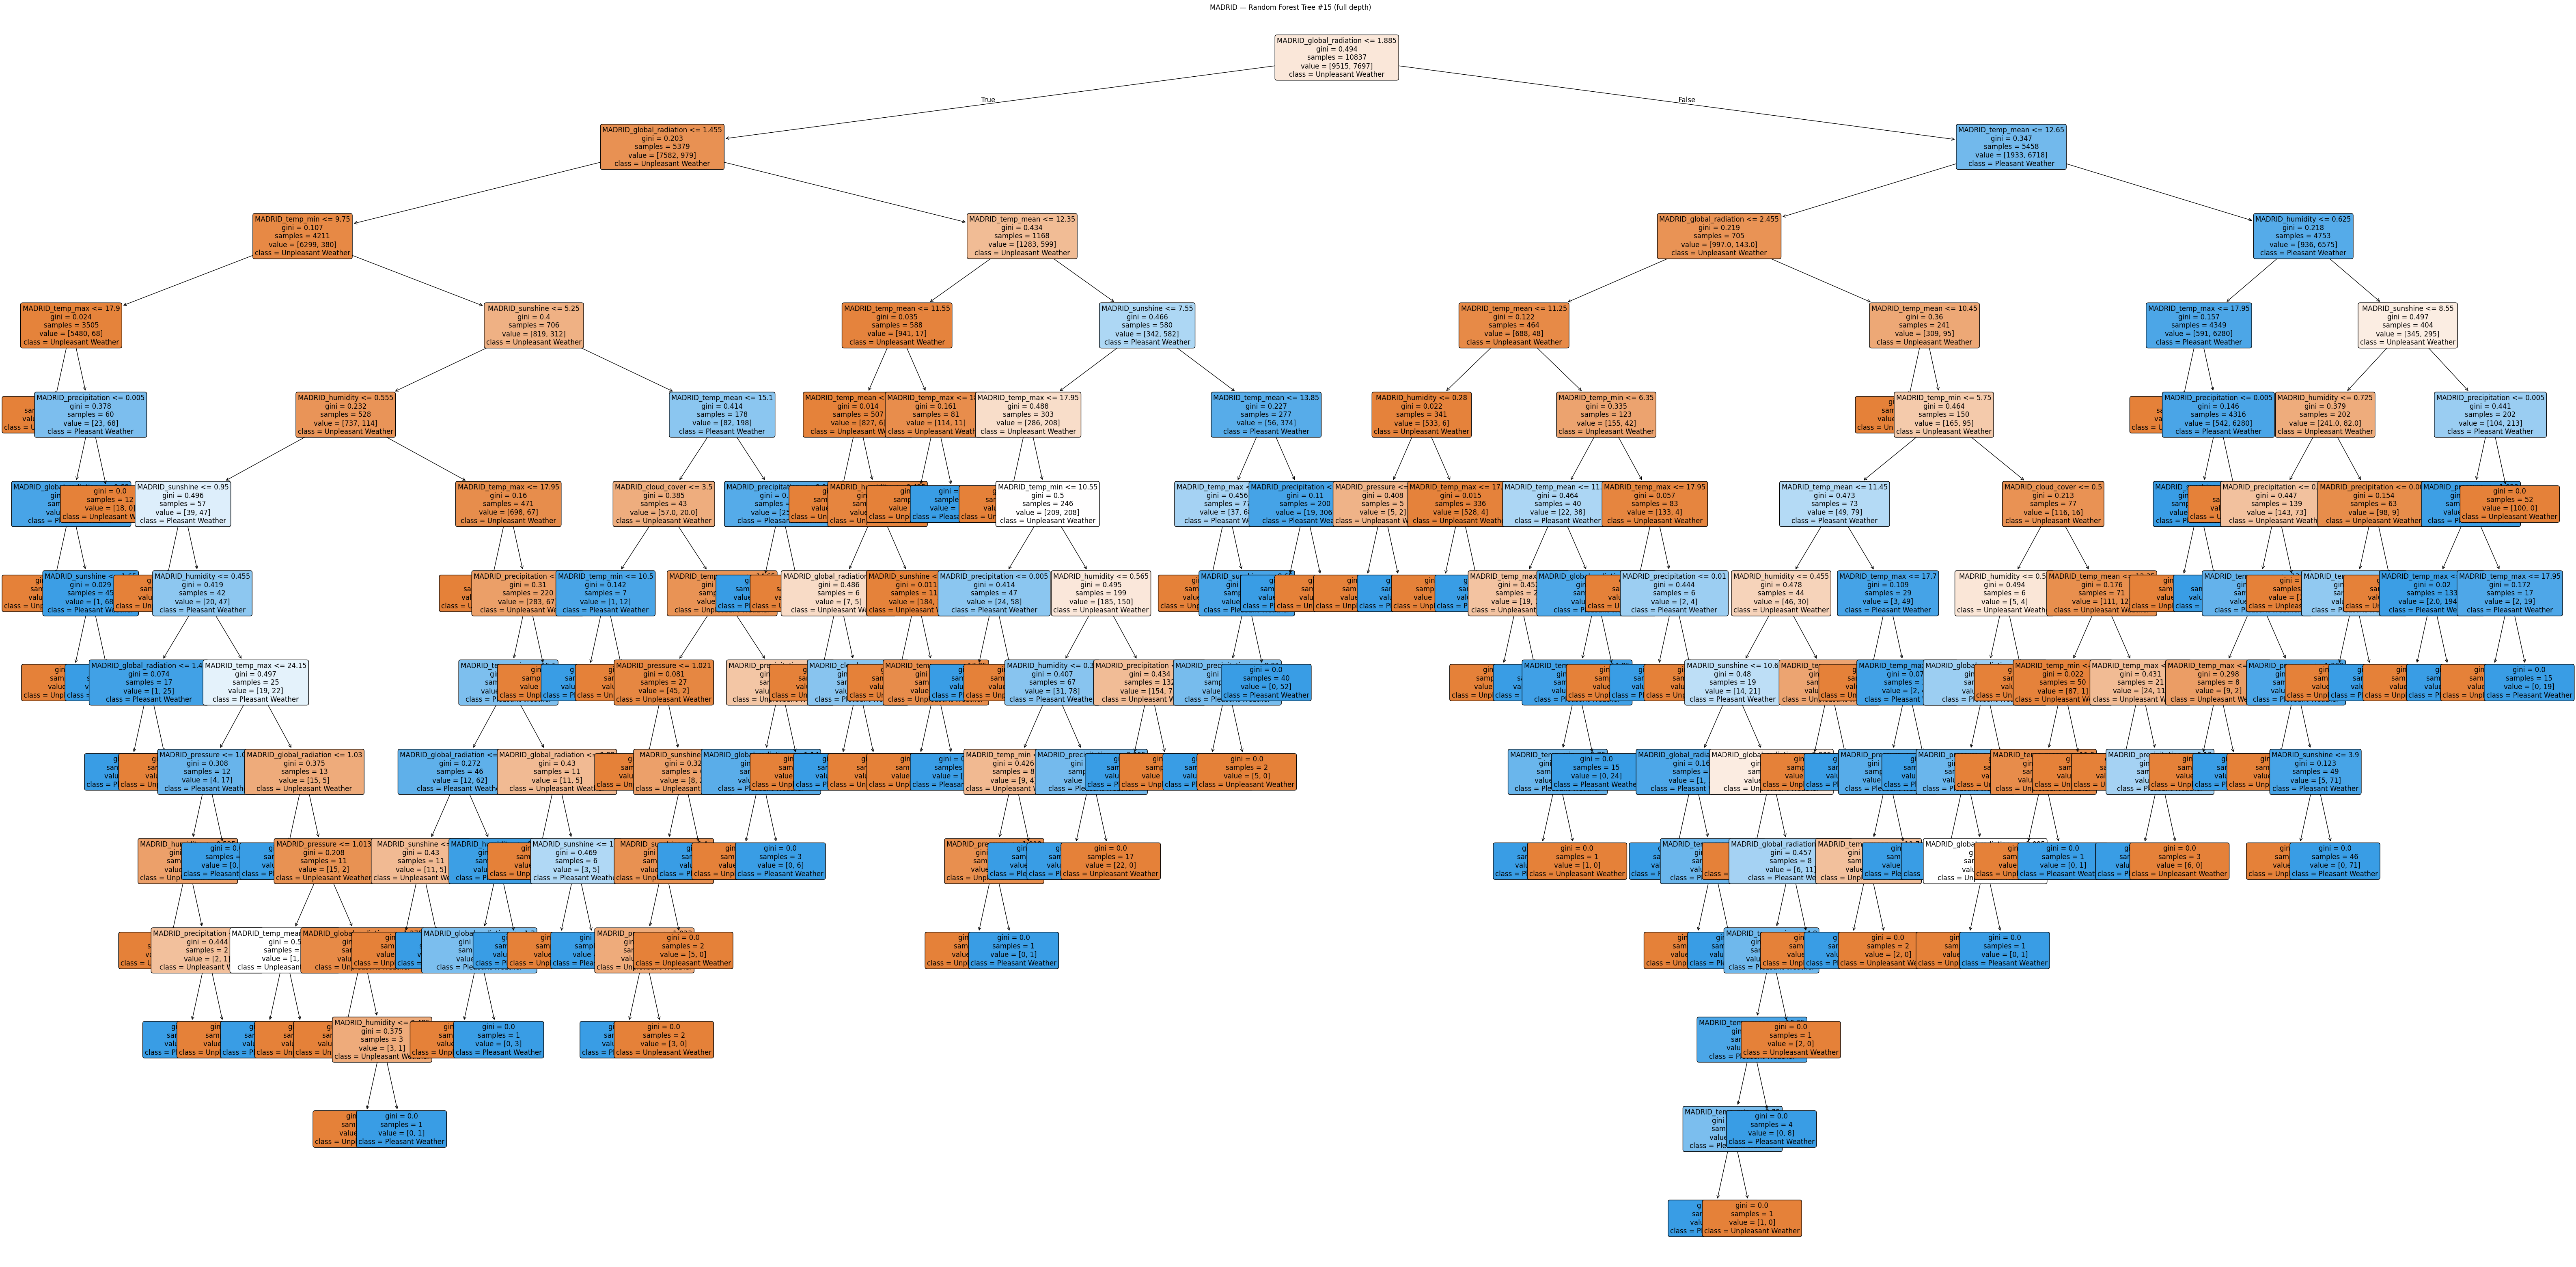

In [20]:
# Plot full Madrid tree
tree_idx = 15

fig = plt.figure(figsize=(80, 40))
plot_tree(
    clf.estimators_[tree_idx],
    filled=True,
    feature_names=list(X_madrid.columns),
    class_names=["Unpleasant Weather", "Pleasant Weather"],
    rounded=True,
    fontsize=12
)

plt.title(f"MADRID — Random Forest Tree #{tree_idx} (full depth)")

file_path = os.path.join(output_dir, f"madrid_rf_tree_{tree_idx}_full.png")
plt.savefig(file_path, bbox_inches="tight", dpi=300)
plt.show()

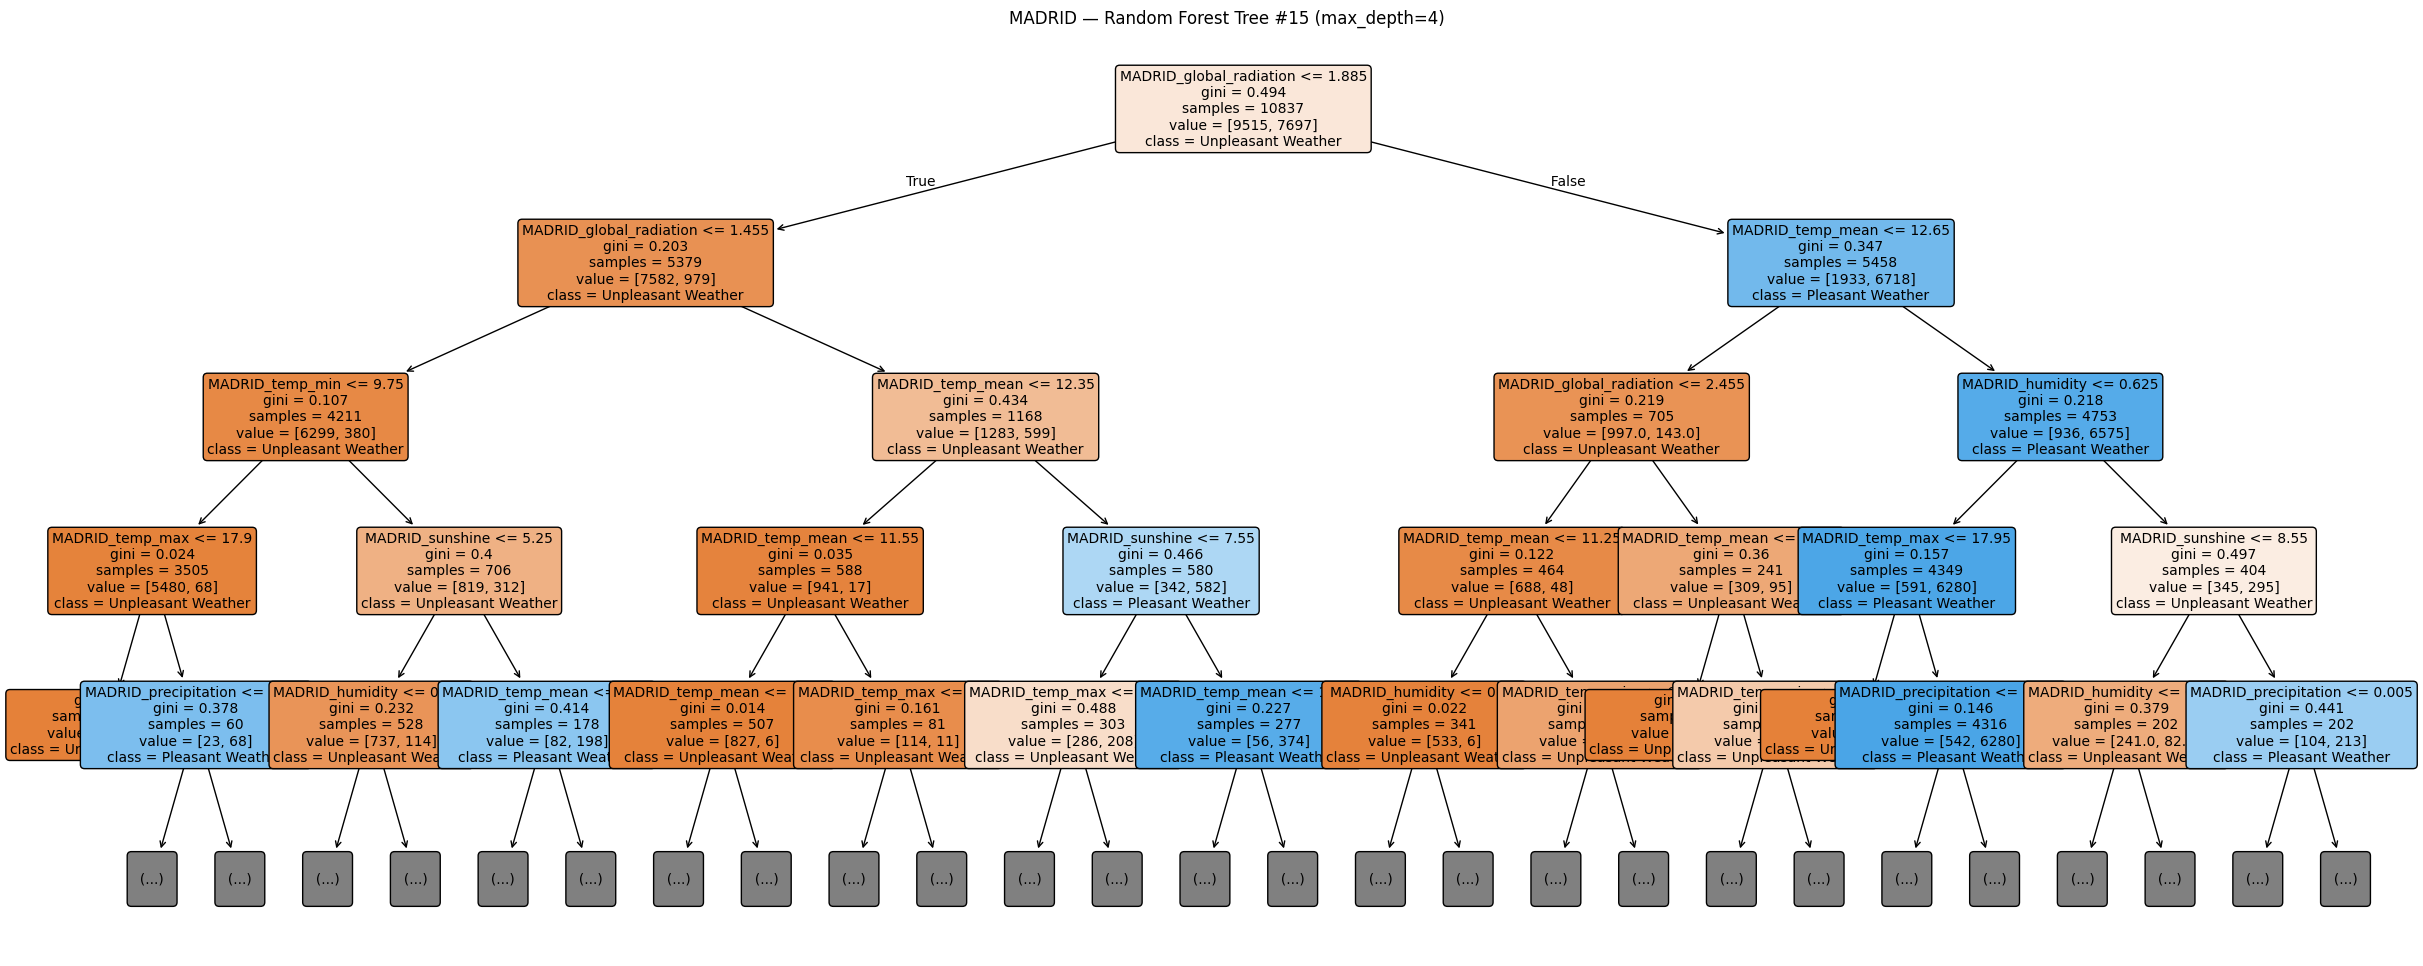

In [21]:
# Plot Madrid tree with max depth = 4

tree_idx = 15

fig = plt.figure(figsize=(30, 12))
plot_tree(
    clf.estimators_[tree_idx],
    filled=True,
    feature_names=list(X_madrid.columns),
    class_names=["Unpleasant Weather", "Pleasant Weather"],
    max_depth=4,
    rounded=True,
    fontsize=10
)

plt.title(f"MADRID — Random Forest Tree #{tree_idx} (max_depth=4)")

file_path = os.path.join(output_dir, f"madrid_rf_tree_{tree_idx}_depth4.png")
plt.savefig(file_path, bbox_inches="tight", dpi=300)
plt.show()

# 6. Feature Importance Analysis

In [22]:
# Define feature importance variable
feature_importances = clf.feature_importances_
print("Feature importances shape:", feature_importances.shape)

Feature importances shape: (9,)


In [23]:
# Define feature names used to train the model
madrid_feature_cols = list(X_madrid.columns)

In [24]:
# Clean labels for plotting
madrid_features_clean = [c.replace("MADRID_", "") for c in madrid_feature_cols]

In [25]:
# Create a Series of importances
important = pd.Series(feature_importances, index=madrid_features_clean).sort_values(ascending=False)
important

temp_max            0.295422
temp_mean           0.219565
precipitation       0.218556
global_radiation    0.121171
sunshine            0.060724
temp_min            0.035558
humidity            0.029631
cloud_cover         0.016719
pressure            0.002653
dtype: float64

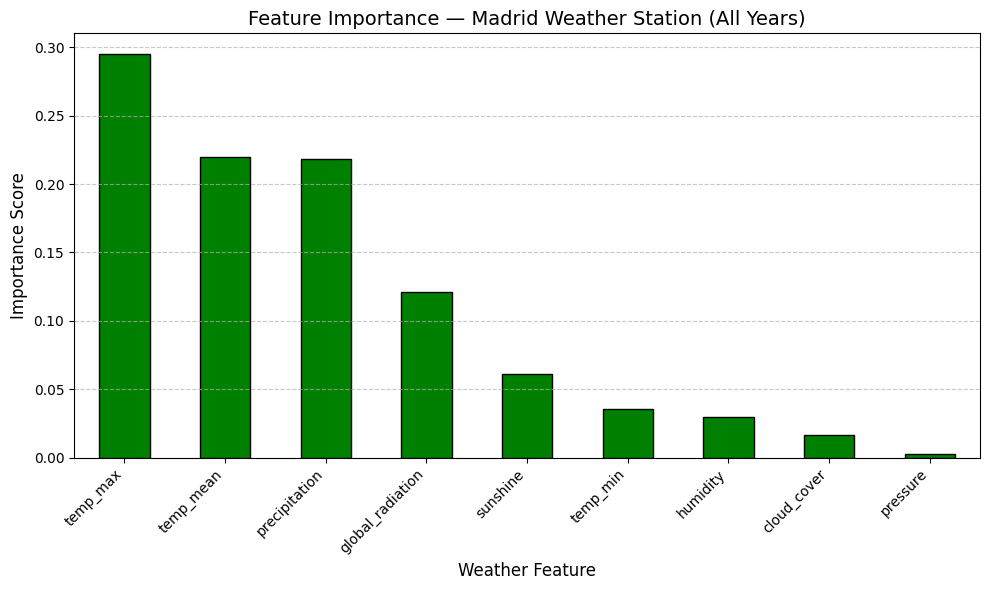

In [26]:
# Plot + export feature importance

plt.figure(figsize=(10, 6))
important.plot(kind="bar", color='green', edgecolor="black")

plt.title("Feature Importance — Madrid Weather Station (All Years)", fontsize=14)
plt.xlabel("Weather Feature", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

file_path = os.path.join(output_dir, "madrid_rf_feature_importance_all_years.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

## <b>Madrid Random Forest — Key Insights</b>

- The Random Forest model achieved 99.98% accuracy on the test set, indicating that Madrid’s weather variables provide an exceptionally strong signal for classifying pleasant versus unpleasant days.
- Maximum temperature is the single most influential feature, with mean temperature close behind. This reflects Madrid’s climate profile, where thermal comfort is the primary determinant of perceived pleasantness.
- Precipitation ranks among the top features, confirming that even in a relatively dry climate, rainfall strongly disrupts pleasant weather conditions.
- Global radiation and sunshine contribute meaningful additional explanatory power, highlighting the role of solar exposure in shaping comfort once temperature thresholds are met.
- Minimum temperature has moderate importance, suggesting overnight or early-morning conditions matter, but less than daytime heat in Madrid’s context.
- Pressure, cloud cover, and humidity contribute very little to the model, indicating that these variables add limited incremental value for pleasant-day classification in Madrid.
- For Madrid-focused modeling, ClimateWins could prioritize temperature metrics and precipitation, supplemented by solar radiation, while deprioritizing pressure-based indicators without substantial loss in predictive accuracy.